In [3]:
import numpy as np
import matplotlib.pyplot as plt 
import random

In [4]:
random.seed(42)

In [5]:
x = np.linspace(-10, 10, 50)
y = 0.5*x**2 +x+2 +np.random.normal(0, 5, 50)
x_re = (np.linspace(-10, 10, 50)).reshape(-1,1)
y_re =( 0.345*x**2 +0.25*x+2+np.random.normal(0, 5, 50)).reshape(-1,1)

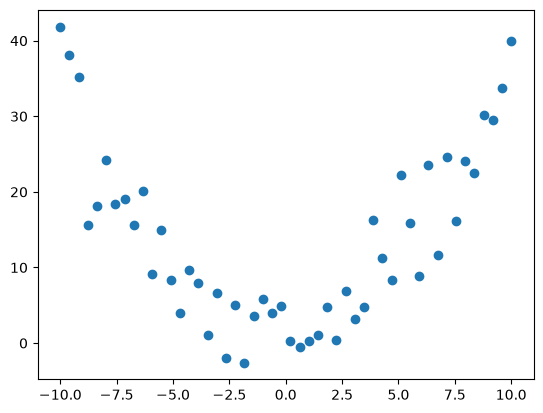

In [6]:
plt.scatter(x_re,y_re)
plt.show()

In [7]:
from sklearn.linear_model import LinearRegression
a=LinearRegression()
a.fit(x_re,y_re)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.13]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[13.74]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[41.65]


In [8]:
a.coef_

array([[0.12562297]])

In [9]:
from sklearn.preprocessing import PolynomialFeatures
b=PolynomialFeatures(degree=3)
tra=b.fit_transform(x_re)

In [10]:
c=LinearRegression()
c.fit(tra,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0. , 1.02, 0.51,-0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.13
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[2835.89, 219.29, 16.63, 0. ]"


In [11]:
z=c.coef_
print(z)

[ 0.          1.01646466  0.51098745 -0.00215065]


In [12]:
nu=z[-1]*x**3+z[-2]*x**2+z[-3]*x+z[0]

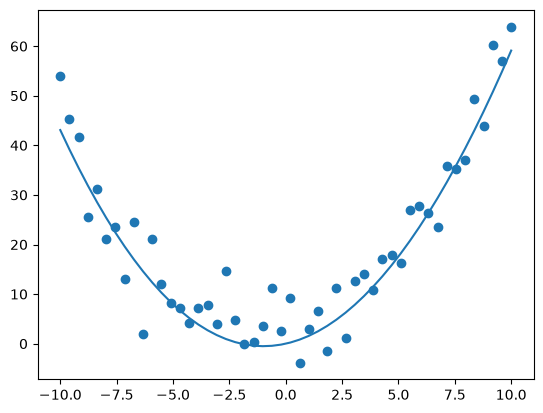

In [13]:
plt.scatter(x,y)
plt.plot(x,nu)
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
def learning_curve(x_whole_trainig_data,y_whole_lable_data,model):
    train_data,val_train,test_data,val_test=train_test_split(x_whole_trainig_data,y_whole_lable_data,random_state=42,test_size=0.4)
    train_error=[]
    validation_error=[]
    for m in range(1,len(train_data)+1):
        model.fit(train_data[:m],test_data[:m])
        train_pred=model.predict(train_data[:m])
        val_pred=model.predict(val_train)
        train_error.append(mean_squared_error(test_data[:m],train_pred))
        validation_error.append(mean_squared_error(val_test,val_pred))
    plt.plot(np.sqrt(train_error), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(validation_error), "b-", linewidth=3, label="val")
    plt.show()
    

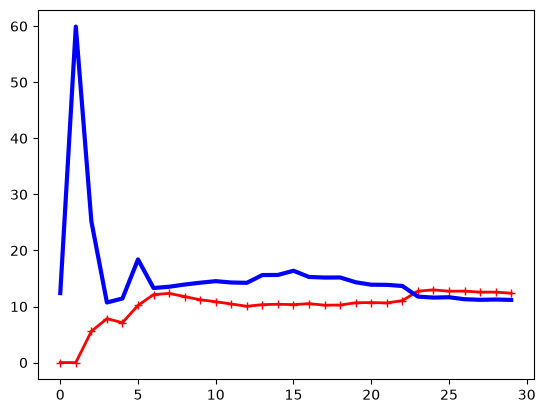

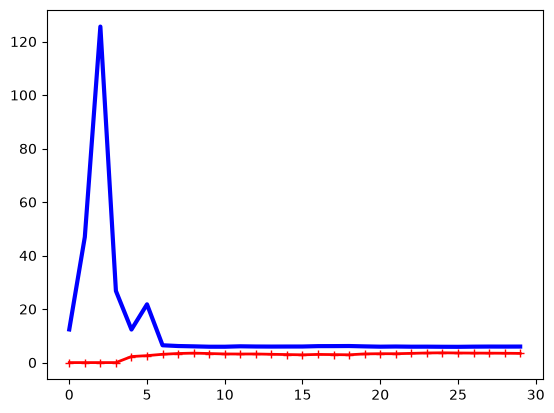

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

higher_deg_pol=Pipeline(
    [
        ("pol_ge",PolynomialFeatures(degree=3,include_bias=False)),
        ("model",LinearRegression())
    ]
)
lin_reg=LinearRegression()
learning_curve(x_re,y_re,lin_reg)
learning_curve(x_re,y_re,higher_deg_pol)